# Freight Rate Prediction — Model Notebook (v2)

**Goal:** predict `posted_rate` (USD) for a truck load from its lane, distance, equipment, weight, date and market signals.

| File | Rows | Dates | Has label |
|---|---|---|---|
| `data/train_test.csv` | 48,000 | 2025-01-01 → 2025-10-31 | yes |
| `data/validation.csv` | 12,000 | 2025-11-01 → 2025-12-31 | no (scored by Spotter) |

The loads we must predict come **after** all labelled data, so all validation here is **time-based**: train on the past, test on the future.

**Contents**
0. Setup & configuration
1. Load the data
2. Exploratory data analysis
3. Data cleaning & feature engineering
4. Modelling: 10 models, grid search, time-series cross-validation
5. Evaluation on the untouched Sep–Oct holdout
6. Final predictions

## 0. Setup & configuration
All settings live here so they are easy to find and change.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 140)

In [2]:
DATA_DIR = Path("data")
RANDOM_STATE = 42

START_DATE = pd.Timestamp("2025-01-01")      # day 0 of the time-trend feature
HOLDOUT_START = pd.Timestamp("2025-09-01")   # Sep–Oct is never used for training or tuning
CV_LAST_TRAIN_MONTHS = [4, 5, 6]             # fold k trains on Jan..month k, tests on the next 2 months
CV_TEST_MONTHS = 2

# A label is "extreme" if it is far outside the normal price band (see EDA 2.9)
EXTREME_LOW, EXTREME_HIGH = 0.6, 1.6

# Plot colours (fixed order) and a quiet default style
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a8984"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "axes.edgecolor": "#b5b4ae",
    "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
})

## 1. Load the data

In [3]:
from typing import Any


def load_data(data_dir):
    train = pd.read_csv(data_dir / "train_test.csv", parse_dates=["date"])
    valid = pd.read_csv(data_dir / "validation.csv", parse_dates=["date"])
    template = pd.read_csv(data_dir / "validation_predictions_template.csv")
    december = pd.read_csv(data_dir / "december_chart_inputs.csv", parse_dates=["date"])
    return train, valid, template, december


train_raw, valid_raw, template, december = load_data(DATA_DIR)

for name, df in [("train_test", train_raw), ("validation", valid_raw),
                 ("template", template), ("december_chart_inputs", december)]:
    print(f"{name:24s} {df.shape}")
    
train_raw.head()

train_test               (48000, 14)
validation               (12000, 13)
template                 (12000, 2)
december_chart_inputs    (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.091,-76.789,38.169,-72.746,274.300,Dry Van,"30,658.000",2025-01-01,0.957,2.396,645.410
1,TR-000002,Richmond,Philadelphia,38.091,-76.789,39.223,-72.967,280.500,Reefer,"17,555.000",2025-01-01,0.976,2.434,679.970
2,TR-000003,Philadelphia,Green Bay,39.223,-72.967,44.303,-87.529,967.800,Dry Van,"31,721.000",2025-01-01,1.010,1.845,"1,802.540"
3,TR-000004,Hartford,Atlanta,39.553,-72.181,34.849,-86.289,965.400,Dry Van,"32,333.000",2025-01-01,0.945,1.877,"1,827.280"
4,TR-000005,Dallas,Nashville,31.830,-94.383,35.295,-88.089,541.900,Reefer,"35,183.000",2025-01-01,0.985,2.563,"1,380.280"


## 2. Exploratory data analysis
### 2.1 Data types and summary statistics

In [4]:
NUMERIC_COLUMNS = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]

# Rate per mile is the most useful way to compare loads of different lengths
train_raw["rate_per_mile"] = train_raw["posted_rate"] / train_raw["distance"]

pd.DataFrame({"dtype": train_raw.dtypes.astype(str), "unique values": train_raw.nunique()})

,dtype,unique values
load_id,object,48000
pickup,object,64
delivery,object,64
pickup_lat,float64,64
pickup_lon,float64,63
delivery_lat,float64,64
delivery_lon,float64,63
distance,float64,21204
equipment,object,3
weight,float64,23678


In [5]:
summary = train_raw[NUMERIC_COLUMNS].describe(percentiles=[0.01, 0.5, 0.99]).T
summary["validation mean"] = valid_raw[NUMERIC_COLUMNS[:-1]].mean()
summary

,count,mean,std,min,1%,50%,99%,max,validation mean
distance,"48,000.000","1,135.857",728.564,70.000,121.899,953.300,"3,029.304","3,439.800","1,141.773"
weight,"47,700.000","31,028.844","9,391.441","-47,500.000","9,801.960","31,436.500","47,500.000","47,500.000","30,506.636"
market_index,"47,626.000",1.083,0.168,0.676,0.783,1.056,1.407,1.468,0.927
quote_signal,"48,000.000",2.062,0.291,0.692,1.305,2.056,2.884,3.610,2.051
posted_rate,"48,000.000","2,373.981","1,486.493",57.220,327.169,"2,030.760","5,972.834","25,533.000",NaN


`weight` has a negative minimum and a round maximum (47,500). `posted_rate` ranges from \$57 to \$25,533. `market_index` is lower on average in validation.

### 2.2 Duplicates and text consistency

In [6]:
print("Duplicate load_id:", train_raw["load_id"].duplicated().sum())
print("Duplicate rows (ignoring load_id):", train_raw.drop(columns="load_id").duplicated().sum())

for column in ["pickup", "delivery", "equipment"]:
    values = pd.concat([train_raw[column], valid_raw[column]])
    extra_spaces = (values != values.str.strip()).sum()
    case_duplicates = values.nunique() - values.str.lower().nunique()
    print(f"{column:10s} {values.nunique():3d} values | extra spaces: {extra_spaces} | case duplicates: {case_duplicates}")

Duplicate load_id: 0
Duplicate rows (ignoring load_id): 0
pickup      72 values | extra spaces: 0 | case duplicates: 0
delivery    72 values | extra spaces: 0 | case duplicates: 0
equipment    3 values | extra spaces: 0 | case duplicates: 0


### 2.3 Missing values

In [7]:
train_missing = train_raw.isna().sum()
valid_missing = valid_raw.isna().sum()

print("Missing values in training data:")
print(train_missing[train_missing > 0])

print("\nMissing values in validation data:")
print(valid_missing[valid_missing > 0])

Missing values in training data:
weight          300
market_index    374
dtype: int64

Missing values in validation data:
weight          165
market_index    249
dtype: int64


Are the gaps random, or do loads with missing values have different prices? We compare rate per mile for rows with and without the gap.

In [8]:
print("Median rate per mile, weight missing vs not:")
print(train_raw.groupby(train_raw["weight"].isna())["rate_per_mile"].median())

print("\nMedian rate per mile, market_index missing vs not:")
print(train_raw.groupby(train_raw["market_index"].isna())["rate_per_mile"].median())

Median rate per mile, weight missing vs not:
weight
False   2.146
True    2.118
Name: rate_per_mile, dtype: float64

Median rate per mile, market_index missing vs not:
market_index
False   2.145
True    2.121
Name: rate_per_mile, dtype: float64


In [9]:
missing_by_month = train_raw.groupby(train_raw["date"].dt.month)[["weight", "market_index"]].apply(lambda d: d.isna().sum())
missing_by_month.T

date,1,2,3,4,5,6,7,8,9,10
weight,34,33,36,20,22,32,29,29,33,32
market_index,36,36,44,31,43,42,36,33,31,42


In [10]:
known = train_raw.dropna(subset=["market_index"])
daily_mean = known.groupby("date")["market_index"].transform("mean")
print(f"Share of market_index variance explained by the date: {daily_mean.var() / known['market_index'].var():.1%}")

Share of market_index variance explained by the date: 97.8%


**Finding:** prices are the same with or without the gap and the gaps are spread evenly over months, so the values are **missing at random**.
* `weight` → fill with the training median.
* `market_index` → almost all of its variation is the date, so fill with **that day's average**.

### 2.4 Negative values

In [11]:
pd.DataFrame({
    "train negatives": (train_raw[NUMERIC_COLUMNS] < 0).sum(),
    "valid negatives": (valid_raw[NUMERIC_COLUMNS[:-1]] < 0).sum(),
})

,train negatives,valid negatives
distance,0,0.000
market_index,0,0.000
posted_rate,0,NaN
quote_signal,0,0.000
weight,292,145.000


Only `weight` has negative values (292 train, 145 validation). A negative weight is impossible, so it is either a **sign error** on a real weight or **garbage**.
If it is a sign error, the absolute values should look exactly like normal weights, and those loads should be priced like normal loads.

In [12]:
positive_weights = train_raw.loc[train_raw["weight"] > 0, "weight"]
flipped_weights = -train_raw.loc[train_raw["weight"] < 0, "weight"]

comparison = pd.DataFrame({
    "positive weights": positive_weights.describe(),
    "|negative weights|": flipped_weights.describe(),
}).T
comparison

,count,mean,std,min,25%,50%,75%,max
positive weights,"47,408.000","31,415.359","7,994.903","5,000.000","25,922.000","31,493.500","37,063.000","47,500.000"
|negative weights|,292.000,"31,724.195","8,262.536","5,000.000","25,928.500","31,821.500","37,284.250","47,500.000"


KS test (same distribution?): p = 0.697


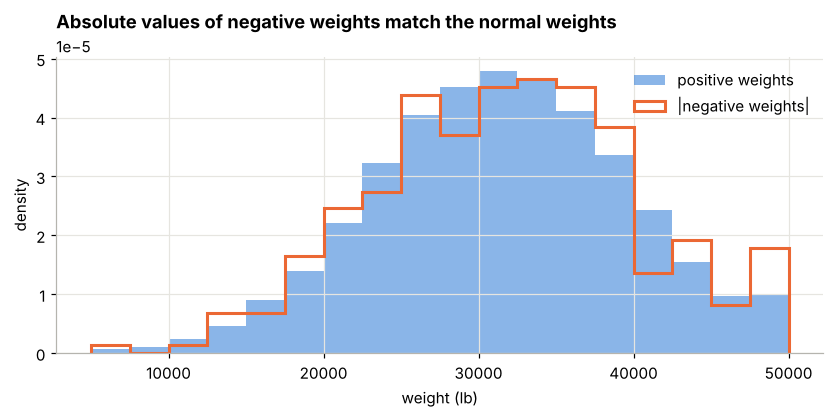

In [13]:
ks_test = stats.ks_2samp(positive_weights, flipped_weights)
print(f"KS test (same distribution?): p = {ks_test.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.arange(5000, 50001, 2500)
ax.hist(positive_weights, bins=bins, density=True, color=BLUE, alpha=0.55, label="positive weights")
ax.hist(flipped_weights, bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE, label="|negative weights|")
ax.set(title="Absolute values of negative weights match the normal weights", xlabel="weight (lb)", ylabel="density")
ax.legend(frameon=False)
plt.show()

**Finding:**  The KS test cannot tell them apart, and they cover the same 5,000–47,500 lb range as normal weights. This is a **sign error**: we take the absolute value and keep the rows.

### 2.5 Clipped values

In [14]:
print("Weight exactly 47,500:", (train_raw["weight"].abs() == 47500).sum())
print("Weight exactly 5,000: ", (train_raw["weight"].abs() == 5000).sum())
print("Distance exactly 70:  ", (train_raw["distance"] == 70).sum())

Weight exactly 47,500: 1204
Weight exactly 5,000:  32
Distance exactly 70:   48


`weight` is clipped to 5,000–47,500 lb and `distance` has a floor of 70 miles. The clipped value is still the best information available, so we keep it.

### 2.6 The target

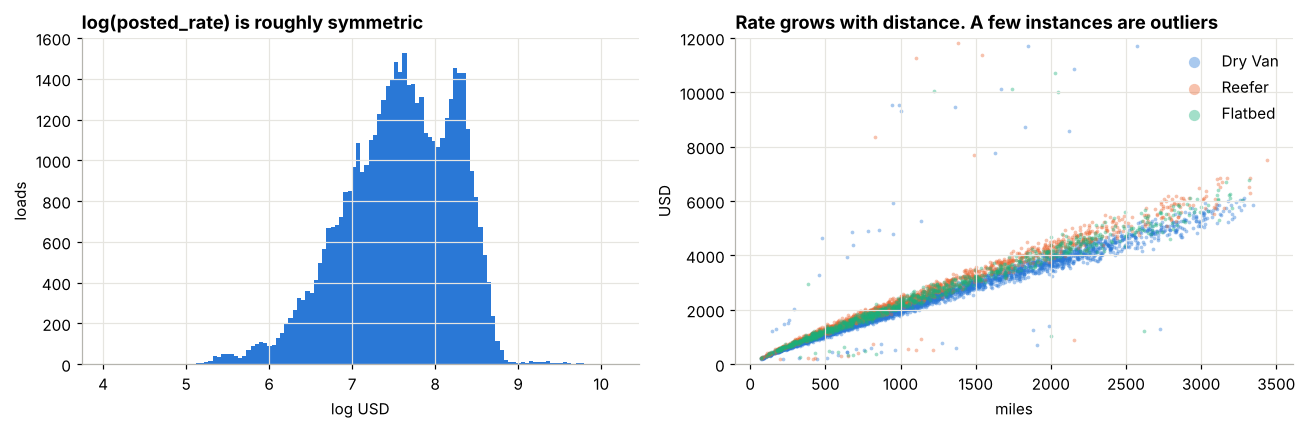

In [15]:
sample = train_raw.sample(6000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log(train_raw["posted_rate"]), bins=120, color=BLUE)
axes[0].set(title="log(posted_rate) is roughly symmetric", xlabel="log USD", ylabel="loads")
for equipment, color in [("Dry Van", BLUE), ("Reefer", ORANGE), ("Flatbed", AQUA)]:
    part = sample[sample["equipment"] == equipment]
    axes[1].scatter(part["distance"], part["posted_rate"], s=6, alpha=0.4, color=color, label=equipment, linewidths=0)
axes[1].set(title="Rate grows with distance. A few instances are outliers", xlabel="miles", ylabel="USD", ylim=(0, 12000))
axes[1].legend(frameon=False, markerscale=3)
plt.tight_layout()
plt.show()

In [16]:
distance_bands = pd.cut(train_raw["distance"], [70, 250, 500, 1000, 2000, 3500])
print("Median $/mile by distance band:")
print(train_raw.groupby(distance_bands, observed=True)["rate_per_mile"].median().round(3).to_string())
print("\nMedian $/mile by equipment:")
print(train_raw.groupby("equipment")["rate_per_mile"].median().round(3).to_string())

Median $/mile by distance band:
distance
(70, 250]      2.740
(250, 500]     2.423
(500, 1000]    2.195
(1000, 2000]   2.046
(2000, 3500]   1.912

Median $/mile by equipment:
equipment
Dry Van   2.046
Flatbed   2.220
Reefer    2.312


Per-mile price falls with distance (a fixed cost plus a per-mile cost), and Reefer and Flatbed cost more than Dry Van.

### 2.7 Market signals over time

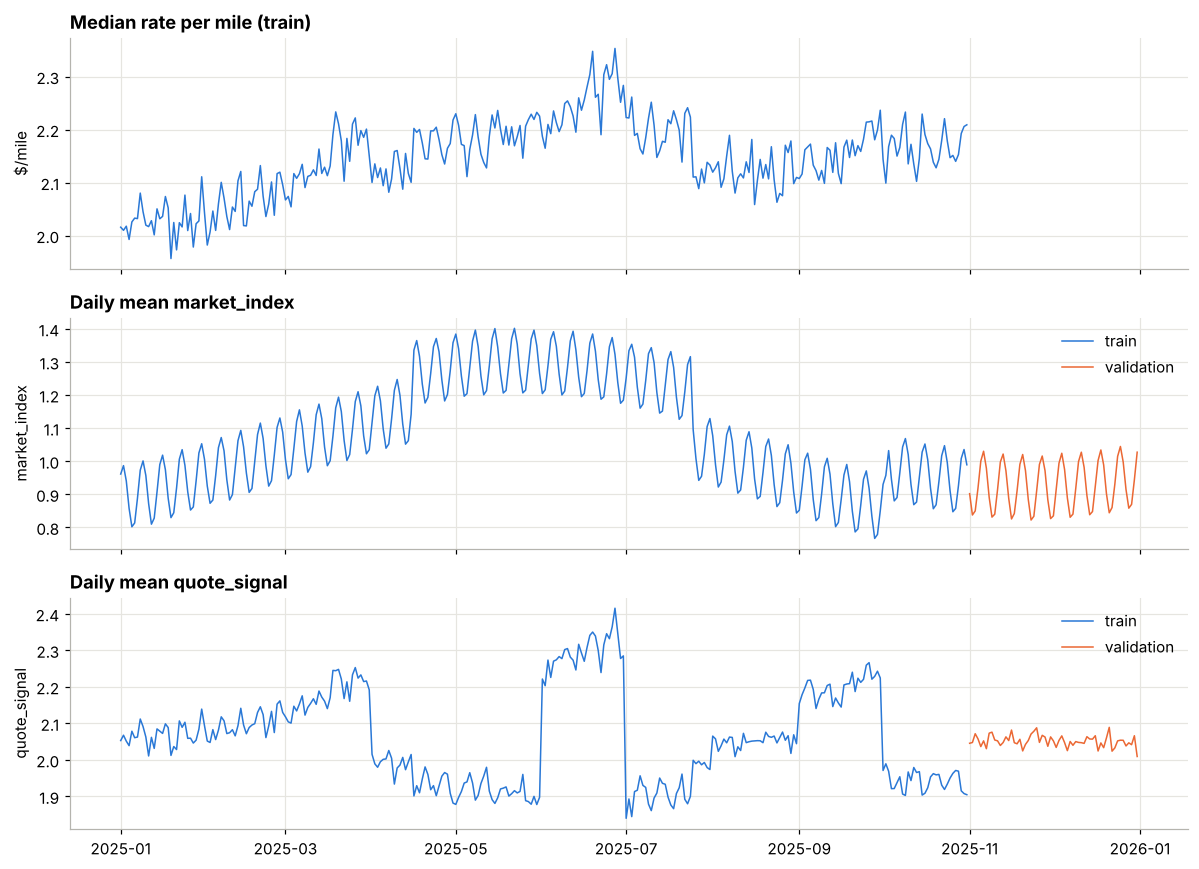

In [17]:
train_daily = train_raw.groupby("date").agg(rate_per_mile=("rate_per_mile", "median"),
                                            market_index=("market_index", "mean"),
                                            quote_signal=("quote_signal", "mean"))
valid_daily = valid_raw.groupby("date").agg(market_index=("market_index", "mean"),
                                            quote_signal=("quote_signal", "mean"))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(train_daily.index, train_daily["rate_per_mile"], color=BLUE, linewidth=1)
axes[0].set(title="Median rate per mile (train)", ylabel="$/mile")
for ax, column in zip(axes[1:], ["market_index", "quote_signal"]):
    ax.plot(train_daily.index, train_daily[column], color=BLUE, linewidth=1, label="train")
    ax.plot(valid_daily.index, valid_daily[column], color=ORANGE, linewidth=1, label="validation")
    ax.set(title=f"Daily mean {column}", ylabel=column)
    ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

In [18]:
weekday = train_raw.groupby(train_raw["date"].dt.day_name())[["rate_per_mile", "market_index"]].mean()
weekday.loc[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]].T

date,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
rate_per_mile,2.196,2.213,2.248,2.245,2.215,2.196,2.192
market_index,1.000,1.075,1.153,1.179,1.134,1.047,0.989


 `market_index`  is effect strongly by weekly cycles. Peaking on thursday
 `quote_signal` jumps up during **March, June and September**

### 2.8 Is there a time trend happening, not just effect from the market index

In [19]:
def distance_equipment_adjusted_log_rate(df):
    # log(rate) minus a simple fit on log(distance) and equipment
    X = np.column_stack([np.ones(len(df)), np.log(df["distance"]),
                         df["equipment"].eq("Reefer"), df["equipment"].eq("Flatbed")]).astype(float)
    y = np.log(df["posted_rate"].to_numpy())
    coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
    return y - X @ coefficients


check = train_raw.dropna(subset=["market_index"]).copy()
check["adjusted"] = distance_equipment_adjusted_log_rate(check)
check = check[check["adjusted"].abs() < 0.4]                       # ignore extreme labels here
same_market = check[check["market_index"].between(0.9, 1.0)]
winter = same_market.loc[same_market["date"].dt.month <= 2, "adjusted"].mean()
autumn = same_market.loc[same_market["date"].dt.month >= 9, "adjusted"].mean()
print(f"Same market level (0.9–1.0): Sep–Oct loads cost {np.exp(autumn - winter) - 1:.1%} more than Jan–Feb loads")

Same market level (0.9–1.0): Sep–Oct loads cost 5.9% more than Jan–Feb loads


**Finding:** prices rise over the year even at the same market level. Tree models cannot extend a trend beyond the training dates, so we include models that can (linear models and the hybrid).

### 2.9 Extreme labels
We compare each label with a simple *expected* price (a log-linear fit) and look at the ratio.

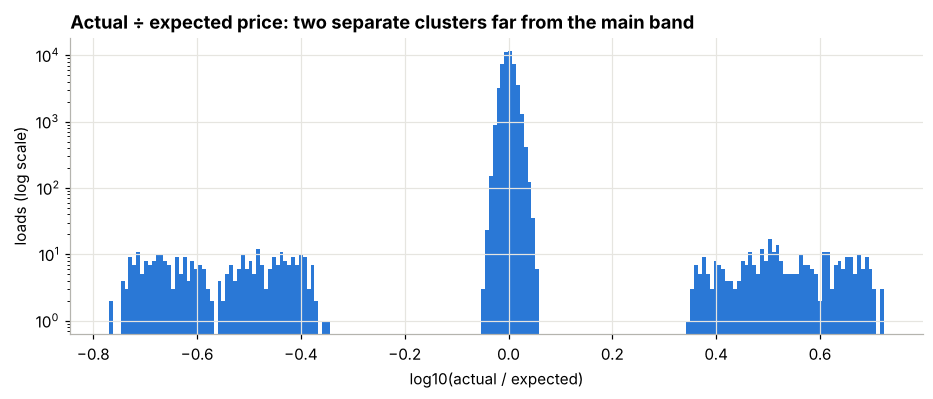

Rows with ratio 0.60–0.75: 0 | 1.3–1.8: 0
Low cluster : 337 rows
High cluster: 340 rows


In [20]:
def expected_price_ratio(df):
    # actual / expected price, using a robust two-pass log-linear fit
    weight = df["weight"].abs().fillna(df["weight"].abs().median())
    market = df["market_index"].fillna(df.groupby("date")["market_index"].transform("mean"))
    days = (df["date"] - START_DATE).dt.days
    X = np.column_stack([
        np.ones(len(df)), np.log(df["distance"]), df["equipment"].eq("Reefer"), df["equipment"].eq("Flatbed"),
        weight / 1e4, market, df["pickup_lat"], df["delivery_lat"], days / 30,
    ]).astype(float)
    y = np.log(df["posted_rate"].to_numpy())

    coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
    normal = np.abs(y - X @ coefficients) < 0.4                     # second pass ignores obvious outliers
    coefficients = np.linalg.lstsq(X[normal], y[normal], rcond=None)[0]
    return pd.Series(np.exp(y - X @ coefficients), index=df.index)


def flag_extreme_labels(df):
    ratio = expected_price_ratio(df)
    return (ratio < EXTREME_LOW) | (ratio > EXTREME_HIGH)


price_ratio = expected_price_ratio(train_raw)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(np.log10(price_ratio), bins=200, color=BLUE)
ax.set_yscale("log")
ax.set(title="Actual ÷ expected price: two separate clusters far from the main band",
       xlabel="log10(actual / expected)", ylabel="loads (log scale)")
plt.show()

print("Rows with ratio 0.60–0.75:", price_ratio.between(0.6, 0.75).sum(), "| 1.3–1.8:", price_ratio.between(1.3, 1.8).sum())
print(f"Low cluster : {(price_ratio < EXTREME_LOW).sum()} rows")
print(f"High cluster: {(price_ratio > EXTREME_HIGH).sum()} rows")

train_raw["is_extreme"] = flag_extreme_labels(train_raw)


### 2.10 What is new in validation?

In [21]:
train_cities = set(train_raw["pickup"]) | set(train_raw["delivery"])
valid_cities = set(valid_raw["pickup"]) | set(valid_raw["delivery"])
new_cities = sorted(valid_cities - train_cities)

print(f"Cities only in validation ({len(new_cities)}): {', '.join(new_cities)}")


Cities only in validation (8): Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego


There is 8 new cities the model has never seen, so we describe their location with their coordinates instead of the city names.

## 3. Data cleaning & feature engineering

In [22]:
WEIGHT_FILL = train_raw["weight"].abs().median()      # learned from training data only


def clean(df):
    df = df.copy()
    df["weight"] = df["weight"].abs().fillna(WEIGHT_FILL)
    same_day_mean = df.groupby("date")["market_index"].transform("mean")
    df["market_index"] = df["market_index"].fillna(same_day_mean)
    return df


def add_features(df):
    df = df.copy()
    df["log_distance"] = np.log(df["distance"])
    df["is_reefer"] = (df["equipment"] == "Reefer").astype(int)
    df["is_flatbed"] = (df["equipment"] == "Flatbed").astype(int)
    df["t_days"] = (df["date"] - START_DATE).dt.days                       # time trend
    df["dow"] = df["date"].dt.dayofweek
    df["mi_day"] = df.groupby("date")["market_index"].transform("mean")     # market level of the day
    df["mi_dev"] = df["market_index"] - df["mi_day"]
    df["qs_day"] = df.groupby("date")["quote_signal"].transform("mean")     # quarter-end regime
    df["qs_dev"] = df["quote_signal"] - df["qs_day"]
    return df


train = add_features(clean(train_raw))
valid = add_features(clean(valid_raw))

print(f"Weight fill value: {WEIGHT_FILL:,.0f} lb")
print("Missing values left   train:", train.isna().sum().sum(), "| validation:", valid.isna().sum().sum())
print("Negative weights left train:", (train["weight"] < 0).sum(), "| validation:", (valid["weight"] < 0).sum())

Weight fill value: 31,496 lb
Missing values left   train: 0 | validation: 0
Negative weights left train: 0 | validation: 0


In [23]:
TREE_FEATURES = [
    "log_distance", "weight", "is_reefer", "is_flatbed",
    "market_index", "mi_day", "mi_dev", "quote_signal", "qs_day", "qs_dev",
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", "dow", "t_days",
]
LINEAR_FEATURES = [
    "log_distance", "weight", "is_reefer", "is_flatbed",
    "market_index", "quote_signal", "qs_day", "pickup_lat", "delivery_lat", "t_days",
]
RESIDUAL_FEATURES = [f for f in TREE_FEATURES if f != "t_days"]   # hybrid stage 2 has no time feature
ALL_COLUMNS = TREE_FEATURES

## 4. Modelling

### 4.1 Data split

We have a hold out set which is Sep–Oct that is kept aside for Step 5 and never used for training or tuning.
The Development set is from Jan–Aug, it is used for grid search with Cross validation

| Fold | Train | Test |
|---|---|---|
| 1 | Jan–Apr | May–Jun |
| 2 | Jan–May | Jun–Jul |
| 3 | Jan–Jun | Jul–Aug |

Extreme labels are removed from the training part of each fold only..

In [24]:
is_dev = train["date"] < HOLDOUT_START
dev = train[is_dev].reset_index(drop=True)
holdout = train[~is_dev].reset_index(drop=True)

X_dev, y_dev = dev[ALL_COLUMNS], dev["posted_rate"]
X_holdout, y_holdout = holdout[ALL_COLUMNS], holdout["posted_rate"]
print(f"Development rows: {len(dev):,} | Holdout rows: {len(holdout):,}")

Development rows: 38,477 | Holdout rows: 9,523


In [25]:
def make_time_folds(df, drop_extremes=True):
    month = df["date"].dt.month
    folds = []
    for last_train_month in CV_LAST_TRAIN_MONTHS:
        train_rows = month <= last_train_month
        if drop_extremes:
            train_rows &= ~df["is_extreme"]
        test_rows = month.between(last_train_month + 1, last_train_month + CV_TEST_MONTHS)
        folds.append((np.where(train_rows)[0], np.where(test_rows)[0]))
    return folds


CV_FOLDS = make_time_folds(dev, drop_extremes=True)
for train_idx, test_idx in CV_FOLDS:
    print(f"train {len(train_idx):6,} rows (months {dev.date.dt.month[train_idx].min()}–{dev.date.dt.month[train_idx].max()}) "
          f"-> test {len(test_idx):6,} rows (months {dev.date.dt.month[test_idx].min()}–{dev.date.dt.month[test_idx].max()})")

train 18,835 rows (months 1–4) -> test  9,696 rows (months 5–6)
train 23,686 rows (months 1–5) -> test  9,695 rows (months 6–7)
train 28,406 rows (months 1–6) -> test  9,671 rows (months 7–8)


### 4.2 Metrics

We use three metrics, MAE, RMSE and R squared

In [26]:
SCORERS = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}


def score_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

### 4.3 Models

Every model tries to predict the **log(rate)** and is converted back to dollars. This keeps errors proportional to the size of the load.

| # | Model | Family | Why |
|---|---|---|---|
| 1 | Linear Regression | linear | simplest model; can extend the time trend |
| 2 | Ridge | linear | regularised linear model |
| 3 | Lasso | linear | regularised linear model that can drop features |
| 4 | K-Nearest Neighbours | instance-based | prices a load like its most similar past loads |
| 5 | Decision Tree | tree | single interpretable tree |
| 6 | Random Forest | tree ensemble | averages many trees |
| 7 | Extra Trees | tree ensemble | more randomised forest |
| 8 | XGBoost | boosting | popular gradient boosting library |
| 9 | LightGBM | boosting | fast leaf-wise boosting |
| 10 | Hybrid: Ridge + LightGBM | linear + boosting | Ridge carries the trend; LightGBM learns the rest |

In [27]:
class RidgePlusLightGBM(BaseEstimator, RegressorMixin):
    # Stage 1: Ridge on LINEAR_FEATURES (includes time, so it extends the trend)
    # Stage 2: LightGBM on what Ridge got wrong, using RESIDUAL_FEATURES (no time feature)

    def __init__(self, alpha=1.0, learning_rate=0.05, num_leaves=15, n_estimators=400):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves
        self.n_estimators = n_estimators

    def fit(self, X, y):
        self.ridge_ = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=self.alpha))])
        self.ridge_.fit(X[LINEAR_FEATURES], y)
        residuals = np.asarray(y) - self.ridge_.predict(X[LINEAR_FEATURES])

        self.lgbm_ = LGBMRegressor(learning_rate=self.learning_rate, num_leaves=self.num_leaves,
                                   n_estimators=self.n_estimators, min_child_samples=50, subsample=0.8,
                                   subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1)
        self.lgbm_.fit(X[RESIDUAL_FEATURES], residuals)
        return self

    def predict(self, X):
        return self.ridge_.predict(X[LINEAR_FEATURES]) + self.lgbm_.predict(X[RESIDUAL_FEATURES])

In [28]:
def log_target_model(regressor, features=None, scale=False):
    # Select columns -> (optionally) scale -> model, trained on log(rate)
    steps = []
    if features is not None:
        steps.append(("select", ColumnTransformer([("keep", "passthrough", features)])))
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", regressor))
    return TransformedTargetRegressor(regressor=Pipeline(steps), func=np.log, inverse_func=np.exp)


boosting_defaults = dict(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)

MODELS = {
    "Linear Regression": (
        log_target_model(LinearRegression(), LINEAR_FEATURES, scale=True), {}),
    "Ridge": (
        log_target_model(Ridge(), LINEAR_FEATURES, scale=True),
        {"regressor__model__alpha": [0.1, 10, 1000]}),
    "Lasso": (
        log_target_model(Lasso(max_iter=5000), LINEAR_FEATURES, scale=True),
        {"regressor__model__alpha": [1e-4, 1e-3, 1e-2]}),
    "K-Nearest Neighbours": (
        log_target_model(KNeighborsRegressor(weights="distance", n_jobs=-1), TREE_FEATURES, scale=True),
        {"regressor__model__n_neighbors": [10, 30]}),
    "Decision Tree": (
        log_target_model(DecisionTreeRegressor(random_state=RANDOM_STATE), TREE_FEATURES),
        {"regressor__model__max_depth": [10, 16], "regressor__model__min_samples_leaf": [10, 50]}),
    "Random Forest": (
        log_target_model(RandomForestRegressor(n_estimators=120, max_features=0.5, n_jobs=-1,
                                               random_state=RANDOM_STATE), TREE_FEATURES),
        {"regressor__model__min_samples_leaf": [5, 20]}),
    "Extra Trees": (
        log_target_model(ExtraTreesRegressor(n_estimators=120, max_features=0.7, n_jobs=-1,
                                             random_state=RANDOM_STATE), TREE_FEATURES),
        {"regressor__model__min_samples_leaf": [2, 10]}),
    "XGBoost": (
        log_target_model(XGBRegressor(n_estimators=600, n_jobs=-1, **boosting_defaults), TREE_FEATURES),
        {"regressor__model__max_depth": [4, 6], "regressor__model__learning_rate": [0.03, 0.08]}),
    "LightGBM": (
        log_target_model(LGBMRegressor(n_estimators=600, min_child_samples=100, subsample_freq=1, verbose=-1,
                                       **boosting_defaults), TREE_FEATURES),
        {"regressor__model__num_leaves": [15, 63], "regressor__model__learning_rate": [0.03, 0.08]}),
    "Hybrid (Ridge + LightGBM)": (
        log_target_model(RidgePlusLightGBM()),
        {"regressor__model__alpha": [1.0, 100.0], "regressor__model__learning_rate": [0.03, 0.08]}),
}

pd.DataFrame({
    "settings tried": [max(1, int(np.prod([len(v) for v in grid.values()]))) for _, grid in MODELS.values()],
}, index=MODELS.keys()).assign(fits=lambda t: t["settings tried"] * len(CV_FOLDS))

,settings tried,fits
Linear Regression,1,3
Ridge,3,9
Lasso,3,9
K-Nearest Neighbours,2,6
Decision Tree,4,12
Random Forest,2,6
Extra Trees,2,6
XGBoost,4,12
LightGBM,4,12
Hybrid (Ridge + LightGBM),4,12


### 4.4 Grid search with time-series cross-validation

In [29]:
def run_grid_search(model, grid, X, y, folds):
    search = GridSearchCV(model, grid, cv=folds, scoring=SCORERS, refit=False, n_jobs=1)
    search.fit(X, y)
    results = pd.DataFrame(search.cv_results_)
    best = results.sort_values("rank_test_MAE").iloc[0]
    return best["params"], best


searches = {}
for name, (model, grid) in MODELS.items():
    best_params, best_row = run_grid_search(model, grid, X_dev, y_dev, CV_FOLDS)
    searches[name] = {"params": best_params, "cv": best_row}
    print(f"{name:27s} CV MAE ${-best_row['mean_test_MAE']:7.2f}   best settings: {best_params}")

Linear Regression           CV MAE $ 113.32   best settings: {}


Ridge                       CV MAE $ 113.22   best settings: {'regressor__model__alpha': 10}


Lasso                       CV MAE $ 111.55   best settings: {'regressor__model__alpha': 0.001}


K-Nearest Neighbours        CV MAE $ 328.95   best settings: {'regressor__model__n_neighbors': 10}


Decision Tree               CV MAE $ 137.71   best settings: {'regressor__model__max_depth': 16, 'regressor__model__min_samples_leaf': 10}


Random Forest               CV MAE $ 133.51   best settings: {'regressor__model__min_samples_leaf': 5}


Extra Trees                 CV MAE $ 113.13   best settings: {'regressor__model__min_samples_leaf': 2}


XGBoost                     CV MAE $ 108.99   best settings: {'regressor__model__learning_rate': 0.08, 'regressor__model__max_depth': 4}


LightGBM                    CV MAE $ 114.36   best settings: {'regressor__model__learning_rate': 0.08, 'regressor__model__num_leaves': 15}


Hybrid (Ridge + LightGBM)   CV MAE $ 108.39   best settings: {'regressor__model__alpha': 100.0, 'regressor__model__learning_rate': 0.03}


In [30]:
def cv_row(cv):
    return {
        "CV MAE $": -cv["mean_test_MAE"],
        "± fold std": cv["std_test_MAE"],
        "CV RMSE $": -cv["mean_test_RMSE"],
        "CV R2": cv["mean_test_R2"],
    }


cv_table = pd.DataFrame({name: cv_row(s["cv"]) for name, s in searches.items()}).T.sort_values("CV MAE $")
cv_table

,CV MAE $,± fold std,CV RMSE $,CV R2
Hybrid (Ridge + LightGBM),108.386,6.650,635.445,0.828
XGBoost,108.989,6.897,638.249,0.826
Lasso,111.555,7.388,637.102,0.827
Extra Trees,113.126,5.452,643.378,0.823
Ridge,113.220,6.169,636.502,0.827
Linear Regression,113.318,6.244,636.493,0.827
LightGBM,114.361,3.753,641.203,0.825
Random Forest,133.515,5.847,648.509,0.821
Decision Tree,137.705,9.907,649.190,0.820
K-Nearest Neighbours,328.945,6.178,755.496,0.757


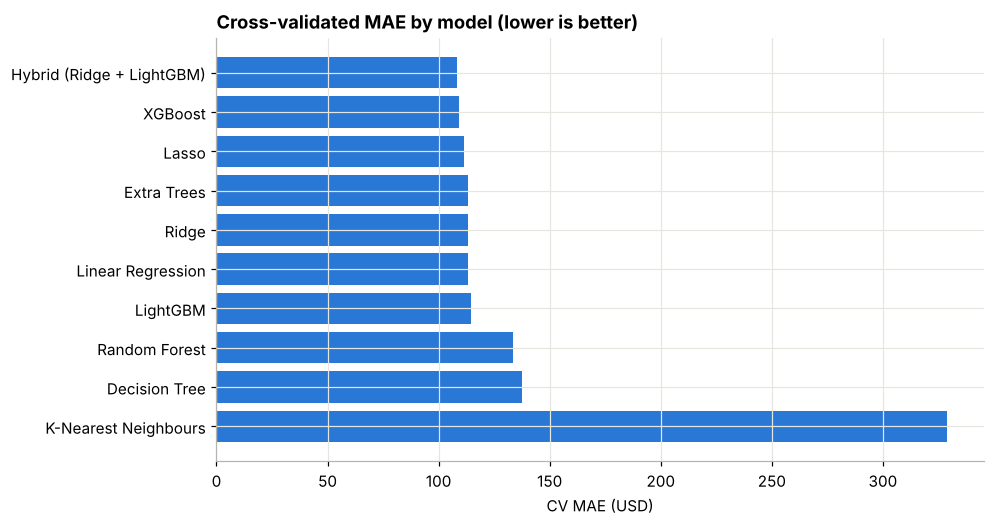

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cv_table.index[::-1], cv_table["CV MAE $"][::-1], color=BLUE)
ax.set(title="Cross-validated MAE by model (lower is better)", xlabel="CV MAE (USD)")
plt.show()

### 4.5 Keep or drop the extreme labels?
Each model is re-scored with its best settings, this time **keeping** the extreme labels in training.

In [32]:
folds_keep = make_time_folds(dev, drop_extremes=False)

rows = []
for name, (model, _) in MODELS.items():
    model_with_best = clone(model).set_params(**searches[name]["params"])
    keep_scores = cross_validate(model_with_best, X_dev, y_dev, cv=folds_keep, scoring={"MAE": SCORERS["MAE"]})
    rows.append({"model": name,
                 "CV MAE $ (drop extremes)": -searches[name]["cv"]["mean_test_MAE"],
                 "CV MAE $ (keep extremes)": -keep_scores["test_MAE"].mean()})

keep_vs_drop = pd.DataFrame(rows).set_index("model")
keep_vs_drop["dropping helps by $"] = keep_vs_drop["CV MAE $ (keep extremes)"] - keep_vs_drop["CV MAE $ (drop extremes)"]
keep_vs_drop.sort_values("CV MAE $ (drop extremes)")

,CV MAE $ (drop extremes),CV MAE $ (keep extremes),dropping helps by $
model,,,
Hybrid (Ridge + LightGBM),108.386,119.138,10.752
XGBoost,108.989,220.221,111.232
Lasso,111.555,112.903,1.348
Extra Trees,113.126,132.845,19.719
Ridge,113.220,113.653,0.433
Linear Regression,113.318,113.705,0.387
LightGBM,114.361,150.620,36.259
Random Forest,133.515,147.722,14.207
Decision Tree,137.705,189.015,51.310


## 5. Evaluation on the Sep–Oct holdout

Each model is trained with its best settings on all of Jan–Aug, and is then tested on Sep–Oct, which no model has seen.

In [33]:
def fit_final_model(name, X, y, is_extreme):
    model, _ = MODELS[name]
    model = clone(model).set_params(**searches[name]["params"])
    return model.fit(X[~is_extreme], y[~is_extreme])


holdout_normal = ~holdout["is_extreme"].to_numpy()
fitted_models, holdout_predictions, rows = {}, {}, []

for name in MODELS:
    fitted_models[name] = fit_final_model(name, X_dev, y_dev, dev["is_extreme"].to_numpy())
    prediction = fitted_models[name].predict(X_holdout)
    holdout_predictions[name] = prediction
    rows.append({"model": name, "rows": "all", **score_predictions(y_holdout, prediction)})
    rows.append({"model": name, "rows": "normal", **score_predictions(y_holdout[holdout_normal], prediction[holdout_normal])})

holdout_results = pd.DataFrame(rows).set_index(["model", "rows"])

In [34]:
normal_results = holdout_results.xs("normal", level="rows").sort_values("MAE")
all_results = holdout_results.xs("all", level="rows").loc[normal_results.index]

holdout_summary = pd.concat({"normal rows": normal_results, "all rows": all_results}, axis=1)
holdout_summary

normal rows               all rows              
                                  MAE    RMSE    R2      MAE    RMSE    R2
model                                                                     
Hybrid (Ridge + LightGBM)      37.341  53.478 0.998   93.426 629.906 0.830
XGBoost                        49.654  72.560 0.997  105.521 633.322 0.828
LightGBM                       51.625  74.453 0.997  107.524 633.421 0.828
Linear Regression              53.047  78.734 0.997  108.927 633.971 0.827
Ridge                          53.154  78.970 0.997  109.032 634.021 0.827
Lasso                          54.812  82.172 0.996  110.671 634.717 0.827
Extra Trees                    59.082  88.213 0.996  114.930 636.639 0.826
Random Forest                  62.163  94.883 0.995  117.906 637.394 0.826
Decision Tree                  70.261 101.868 0.995  125.972 638.637 0.825
K-Nearest Neighbours          283.238 406.409 0.913  335.759 758.724 0.753

Best model: Hybrid (Ridge + LightGBM)
Normal-row MAE: $37.34


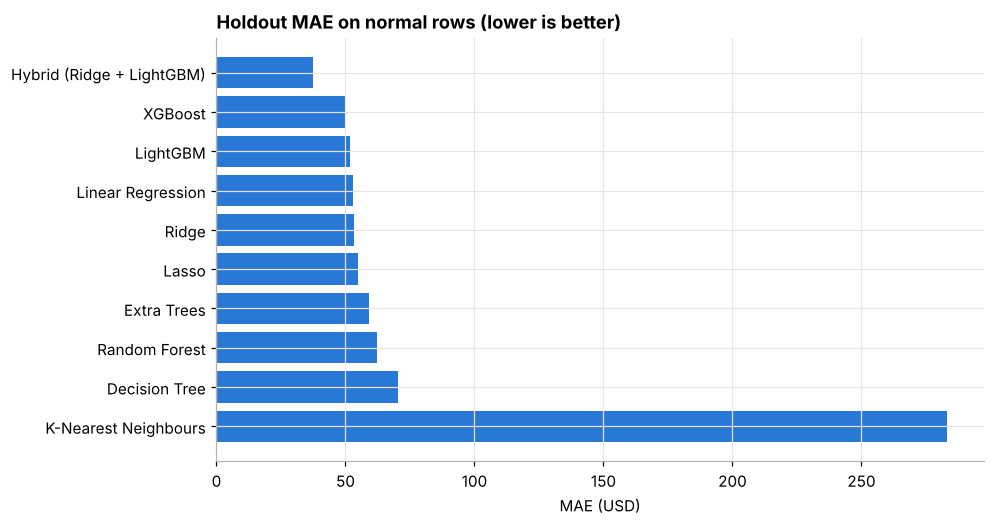

In [35]:
BEST_MODEL = normal_results.index[0]
best_mae = normal_results.loc[BEST_MODEL, "MAE"]
print(f"Best model: {BEST_MODEL}")
print(f"Normal-row MAE: ${best_mae:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(normal_results.index[::-1], normal_results["MAE"][::-1], color=BLUE)
ax.set(title="Holdout MAE on normal rows (lower is better)", xlabel="MAE (USD)")
plt.show()

### 5.1 Where does the best model make errors?

In [36]:
results = holdout.assign(prediction=holdout_predictions[BEST_MODEL])
results["signed_pct_error"] = 100 * (results["prediction"] / results["posted_rate"] - 1)
results["distance band"] = pd.cut(results["distance"], [0, 250, 500, 1000, 2000, 4000])
normal_rows = results[~results["is_extreme"]]


def error_breakdown(column):
    grouped = normal_rows.groupby(column, observed=True)
    return pd.DataFrame({"loads": grouped.size(),
                         "bias %": grouped["signed_pct_error"].mean()})


for column in ["equipment", "distance band"]:
    print(f"\nBy {column}:")
    print(error_breakdown(column).round(2).to_string())


By equipment:
           loads  bias %
equipment               
Dry Van     5275  -0.490
Flatbed     1746  -0.470
Reefer      2358  -0.460

By distance band:
               loads  bias %
distance band               
(0, 250]         544  -0.810
(250, 500]      1511  -0.570
(500, 1000]     2927  -0.450
(1000, 2000]    2884  -0.420
(2000, 4000]    1513  -0.450


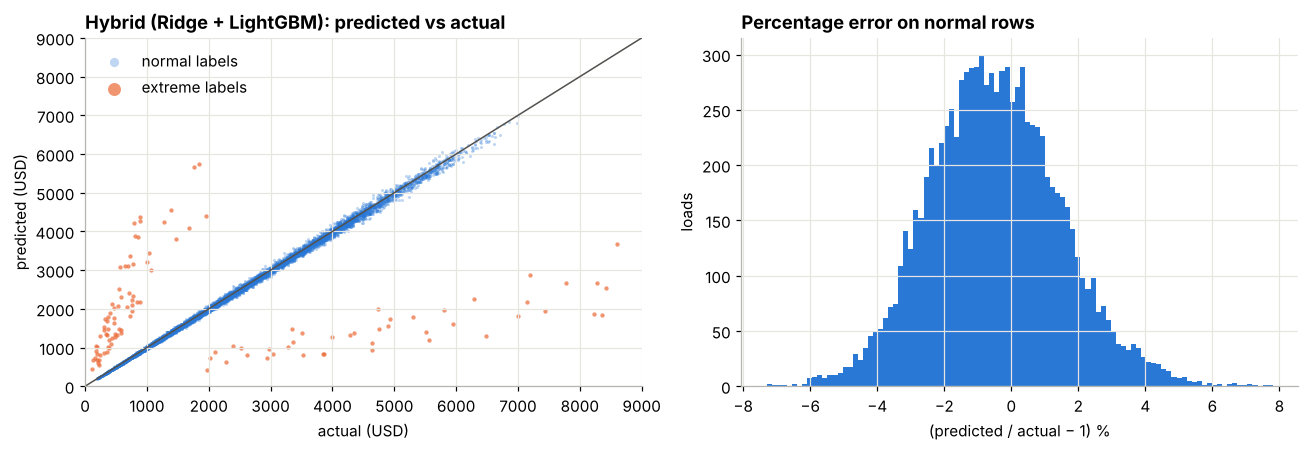

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
normal, extreme = results[~results["is_extreme"]], results[results["is_extreme"]]
axes[0].scatter(normal["posted_rate"], normal["prediction"], s=4, alpha=0.3, color=BLUE, linewidths=0, label="normal labels")
axes[0].scatter(extreme["posted_rate"], extreme["prediction"], s=8, alpha=0.7, color=ORANGE, linewidths=0, label="extreme labels")
axes[0].plot([0, 9000], [0, 9000], color="#52514e", linewidth=1)
axes[0].set(xlim=(0, 9000), ylim=(0, 9000), title=f"{BEST_MODEL}: predicted vs actual", xlabel="actual (USD)", ylabel="predicted (USD)")
axes[0].legend(frameon=False, markerscale=3)
axes[1].hist(normal["signed_pct_error"], bins=100, color=BLUE)
axes[1].set(title="Percentage error on normal rows", xlabel="(predicted / actual − 1) %", ylabel="loads")
plt.tight_layout()
plt.show()

### 5.2 What drives the price?
The Ridge part of the hybrid is directly interpretable: each row shows how much the price changes when one feature changes and everything else stays the same.

In [38]:
hybrid = fitted_models["Hybrid (Ridge + LightGBM)"].regressor_.named_steps["model"]
ridge = hybrid.ridge_.named_steps["ridge"]
scale = hybrid.ridge_.named_steps["scale"].scale_
per_unit = pd.Series(ridge.coef_ / scale, index=LINEAR_FEATURES)

STEP_SIZES = {
    "log_distance": ("+10% distance", np.log(1.1)), "weight": ("+10,000 lb", 1e4),
    "is_reefer": ("Reefer vs Dry Van", 1), "is_flatbed": ("Flatbed vs Dry Van", 1),
    "market_index": ("+0.1 index", 0.1), "quote_signal": ("+0.1 load signal", 0.1),
    "qs_day": ("+0.1 daily signal", 0.1), "pickup_lat": ("pickup 1° further north", 1),
    "delivery_lat": ("delivery 1° further north", 1), "t_days": ("one month later", 30.4),
}
pd.DataFrame({
    "change": [STEP_SIZES[f][0] for f in LINEAR_FEATURES],
    "effect on price %": [100 * (np.exp(per_unit[f] * STEP_SIZES[f][1]) - 1) for f in LINEAR_FEATURES],
}, index=LINEAR_FEATURES).round(2)

,change,effect on price %
log_distance,+10% distance,8.610
weight,"+10,000 lb",3.000
is_reefer,Reefer vs Dry Van,12.800
is_flatbed,Flatbed vs Dry Van,8.150
market_index,+0.1 index,1.640
quote_signal,+0.1 load signal,0.080
qs_day,+0.1 daily signal,0.570
pickup_lat,pickup 1° further north,-0.350
delivery_lat,delivery 1° further north,-0.350
t_days,one month later,0.560


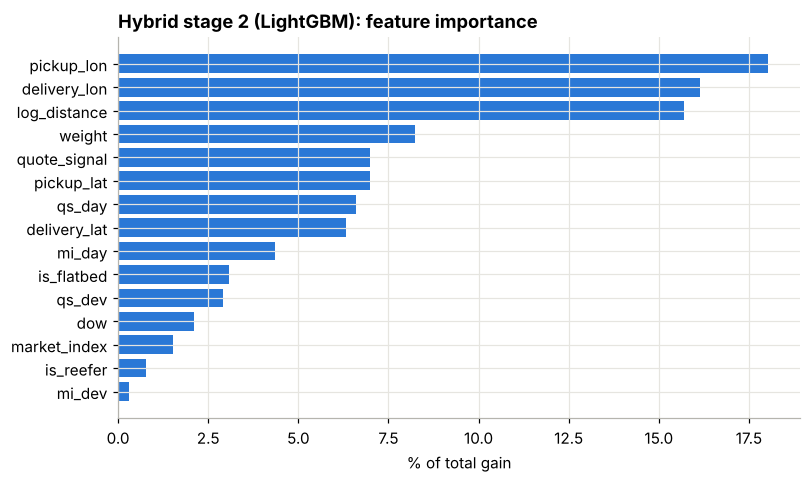

In [39]:
importance = pd.Series(hybrid.lgbm_.booster_.feature_importance("gain"), index=RESIDUAL_FEATURES)
importance = 100 * importance / importance.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importance.sort_values().index, importance.sort_values().values, color=BLUE)
ax.set(title="Hybrid stage 2 (LightGBM): feature importance", xlabel="% of total gain")
plt.show()

## 6. Final predictions

The hybrid is re-trained on all of Jan–Oct (without the extreme labels) using its best settings from the grid search, so it learns from the two most recent months as well. It then predicts:
1. every load in `validation.csv` → `validation_predictions.csv`
2. the 31 December chart rows → `data/december_chart_inputs.csv`

In [40]:
FINAL_MODEL = "Hybrid (Ridge + LightGBM)"

final_model = fit_final_model(FINAL_MODEL, train[ALL_COLUMNS], train["posted_rate"], train["is_extreme"].to_numpy())
print(f"{FINAL_MODEL} trained on {(~train['is_extreme']).sum():,} loads (Jan–Oct, extreme labels removed)")

Hybrid (Ridge + LightGBM) trained on 47,323 loads (Jan–Oct, extreme labels removed)


### 6.1 Validation loads

In [41]:
valid_predictions = pd.DataFrame({
    "load_id": valid["load_id"],
    "predicted_rate": final_model.predict(valid[ALL_COLUMNS]).round(2),
})

# Same IDs and order as the template
submission = template[["load_id"]].merge(valid_predictions, on="load_id", how="left")
submission.to_csv("validation_predictions.csv", index=False)

print("Rows:", len(submission))
print("Missing predictions:", submission["predicted_rate"].isna().sum())
print("Non-positive predictions:", (submission["predicted_rate"] <= 0).sum())
submission.head()

Rows: 12000
Missing predictions: 0
Non-positive predictions: 0


,load_id,predicted_rate
0,TE-000001,849.120
1,TE-000002,"5,110.200"
2,TE-000003,"5,217.750"
3,TE-000004,"4,075.310"
4,TE-000005,"1,875.500"


### 6.2 December chart rows

Every row has the same thing going on. Lexington to Fort Wayne, 360 miles, Dry Van, 32,000 lb. Only the date changes. The file has no coordinates, `market_index` or `quote_signal`, so we fill them in:
* **Coordinates:** taken from the same cities in the training data.
* **`market_index` and `quote_signal`:** that day's average in `validation.csv`, which covers December.

In [42]:
december_loads = december.drop(columns="predicted_rate")

# City coordinates from the training data
pickup_city = december_loads["pickup"].iloc[0]
delivery_city = december_loads["delivery"].iloc[0]
december_loads["pickup_lat"] = train.loc[train["pickup"] == pickup_city, "pickup_lat"].iloc[0]
december_loads["pickup_lon"] = train.loc[train["pickup"] == pickup_city, "pickup_lon"].iloc[0]
december_loads["delivery_lat"] = train.loc[train["delivery"] == delivery_city, "delivery_lat"].iloc[0]
december_loads["delivery_lon"] = train.loc[train["delivery"] == delivery_city, "delivery_lon"].iloc[0]

# Market signals: that day's average in the validation data
daily_market = valid.groupby("date")[["market_index", "quote_signal"]].mean()
december_loads = december_loads.join(daily_market, on="date")

december_loads = add_features(clean(december_loads))
december["predicted_rate"] = final_model.predict(december_loads[ALL_COLUMNS]).round(2)
december.to_csv(DATA_DIR / "december_chart_inputs.csv", index=False)
december

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,828.980
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,834.870
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,842.610
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,846.610
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,841.540
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,833.020
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,829.650
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,830.790
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,836.650
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,844.100
